{
    'topic': '猫',
    'poem': 
'猫は月光を舐めて\n硝子の眼を瞬かせる\n\n傷ついた蜜柑の皮のように\n柔らかな時間が剥がれ落ちる\n\nソファの背で伸びを
する影\n影の内側に眠る海\n\n白い息が\n静かに、静かに\n部屋中の魚を逃がしていく\n\n誰もいない午後\n猫だけが真実を知
っている\n誰もいない午後\n猫だけが嘘をつかない',
    'content_type': '詩'
}

{
    'topic': '猫',
    'joke': 'もちろんです！猫をテーマにしたジョークをいくつかどうぞ。\n\n---\n\n**ジョーク1（パソコン編）**  
\n飼い主が猫に言いました。  \n「お前、なんで俺のパソコンのキーボードの上で寝るんだ？」  
\n猫：「だって、“にゃんこ”って文字を打つとき、お前の指が一番動くんだもん。」\n\n---\n\n**ジョーク2（医者編）**  
\n猫が病院に行きました。  \n医者：「どうしましたか？」  \n猫：「最近、どうも眠りが浅くて…」  
\n医者：「なるほど。じゃあ、まずそのヒゲでベッドの端を測ってみようか。」\n\n---\n\n**ジョーク3（雑貨店編）**  
\n雑貨店で猫が買い物をしていました。  \n店員：「何かお探しですか？」  
\n猫：「“猫じゃらし”を探してるんだけど、ここに売ってる？」  \n店員：「ええ、奥の棚にありますよ。」  
\n猫：「ありがとう。でも、あれ、お店の人が勝手に動かすから、なかなか捕まえられないんだよね。」\n\n---\n\n**ジョーク
4（カレンダー編）**  \n猫がカレンダーを見て言いました。  \n「月曜日は“月”だし、火曜日は“火”だし… 
どうして、猫の日はないの？」  \n飼い主：「そう言うなら、今日から“にゃんデー”にしようか？」  
\n猫：「それ、毎日じゃないと意味ないから。」\n\n---\n\n**ジョーク5（哲学編）**  \n猫が哲学者に尋ねました。  
\n「“私は考える、ゆえに私は在る”ってやつ、本当？」  \n哲学者：「そうだよ。」  
\n猫：「ふーん。でも、私は考える前に“寝る”から、存在しないことになるの？」  
\n哲学者：「…………（哲学者、沈黙）。」\n\n---\n\nもし特定のシチュエーション（職場、学校、ペットあるあるなど）で笑わせ
たいというのがあれば、もっとその方向に寄せて書くこともできますよ。',
    'content_type': 'ジョーク'
}

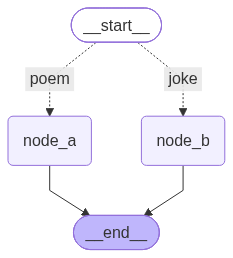

In [2]:
from typing import TypedDict, Literal
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from rich import print

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


#1. 状態を定義
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str


#2. ノードを定義
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"{state['topic']}をテーマにした詩を書いてください"]).content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"{state['topic']}をテーマにしたジョークを書いてください"]).content
    return {
        "joke": joke
    }


def my_route(state: OverAllState) -> Literal["poem", "joke"]:
    if "詩" in state["content_type"]:
        return "poem"
    else:
        return "joke"


#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)

builder.add_conditional_edges(START, my_route, path_map={
    "poem": "node_a",
    "joke": "node_b"
})
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫", "content_type": "詩"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫", "content_type": "ジョーク"})
print(joke_res)

from IPython.display import display

display(graph)
